In [ ]:
!pip install sunpy astropy scikit-image -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.9 MB/s eta 0:00:00


In [ ]:
import os

for f in os.listdir():
    if f.endswith(".fits"):
        print(f)

In [ ]:
import os

for f in os.listdir():
    print(f)

.config
suit_2026Jun25T144118111.zip
sample_data


In [ ]:
import zipfile

with zipfile.ZipFile("suit_2026Jun25T144118111.zip", "r") as z:
    z.extractall()

print("Extracted successfully")

Extracted successfully


In [ ]:
import os

for f in os.listdir():
    if f.endswith(".fits"):
        print(f)

SUT_T26_0957_002214_Lev1.0_2026-06-24T22.19.36.694_08B3NB03.fits


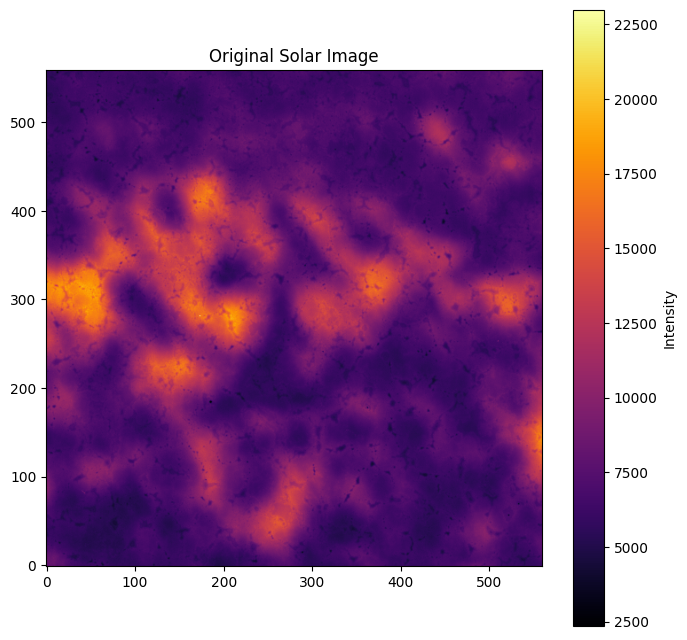

In [ ]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

filename = "SUT_T26_0957_002214_Lev1.0_2026-06-24T22.19.36.694_08B3NB03.fits"

hdul = fits.open(filename)

img = None
for hdu in hdul:
    if hdu.data is not None:
        if len(hdu.data.shape) >= 2:
            img = hdu.data.astype(float)
            break

hdul.close()

img = np.nan_to_num(img)

plt.figure(figsize=(8,8))
plt.imshow(img, origin='lower', cmap='inferno')
plt.colorbar(label='Intensity')
plt.title("Original Solar Image")
plt.show()

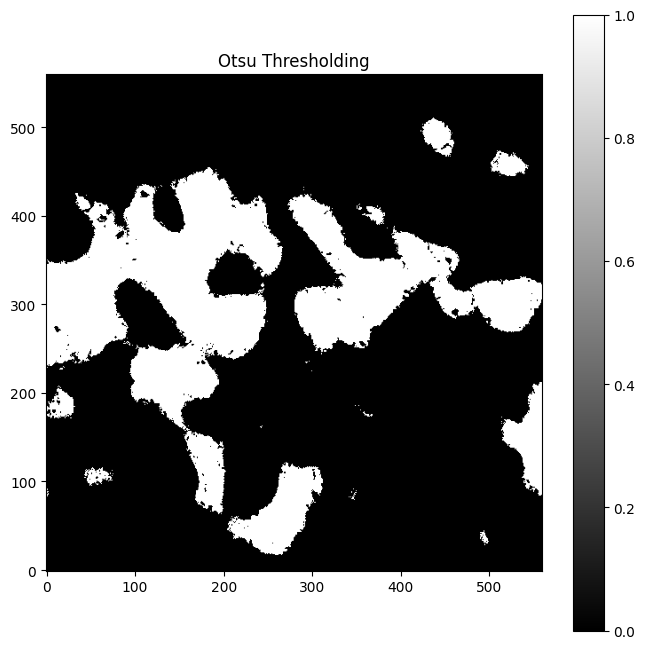

Otsu Threshold Value: 9573.04296875
Detected Pixels: 72094


In [ ]:
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

threshold = threshold_otsu(img)

otsu_mask = img > threshold

plt.figure(figsize=(8,8))
plt.imshow(otsu_mask, cmap="gray", origin="lower")
plt.title("Otsu Thresholding")
plt.colorbar()
plt.show()

print("Otsu Threshold Value:", threshold)
print("Detected Pixels:", otsu_mask.sum())

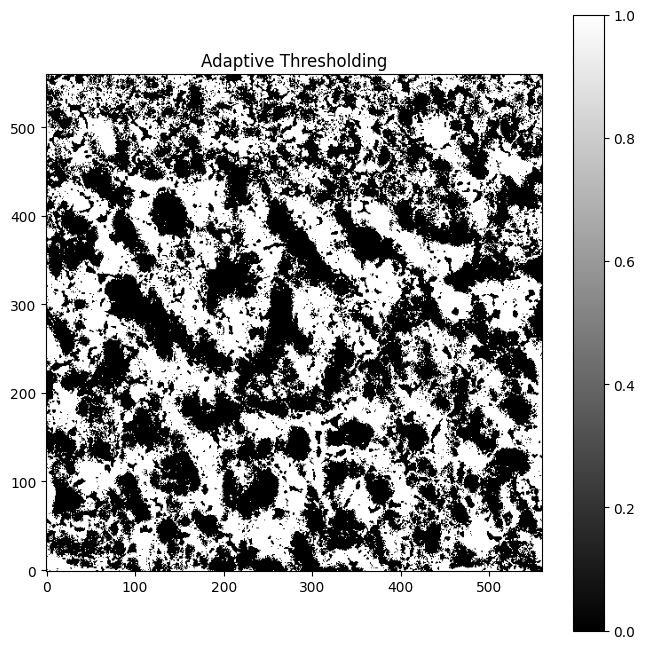

Detected Pixels: 151195


In [ ]:
from skimage.filters import threshold_local
import matplotlib.pyplot as plt

block_size = 51

adaptive_thresh = threshold_local(img, block_size, offset=0)

adaptive_mask = img > adaptive_thresh

plt.figure(figsize=(8,8))
plt.imshow(adaptive_mask, cmap="gray", origin="lower")
plt.title("Adaptive Thresholding")
plt.colorbar()
plt.show()

print("Detected Pixels:", adaptive_mask.sum())

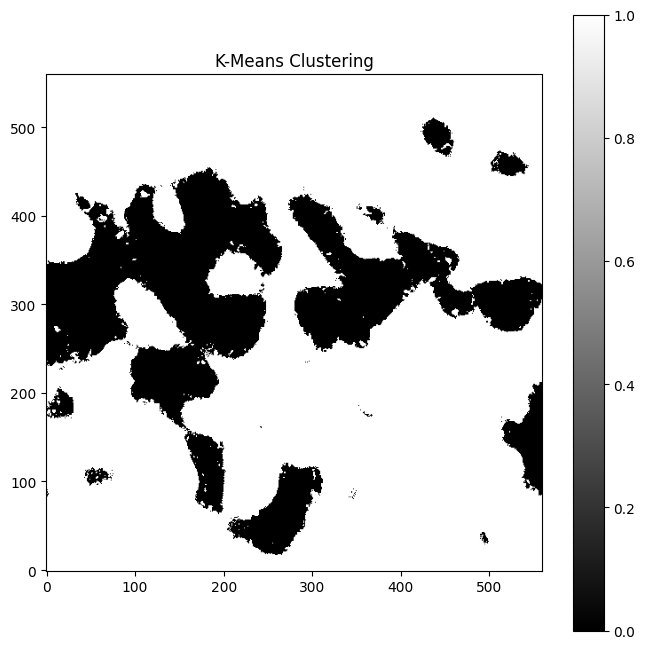

Cluster 0 Pixels: 71299
Cluster 1 Pixels: 242301


In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

pixels = img.reshape(-1, 1)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)

clustered = labels.reshape(img.shape)

plt.figure(figsize=(8,8))
plt.imshow(clustered, cmap="gray", origin="lower")
plt.title("K-Means Clustering")
plt.colorbar()
plt.show()

print("Cluster 0 Pixels:", np.sum(clustered == 0))
print("Cluster 1 Pixels:", np.sum(clustered == 1))

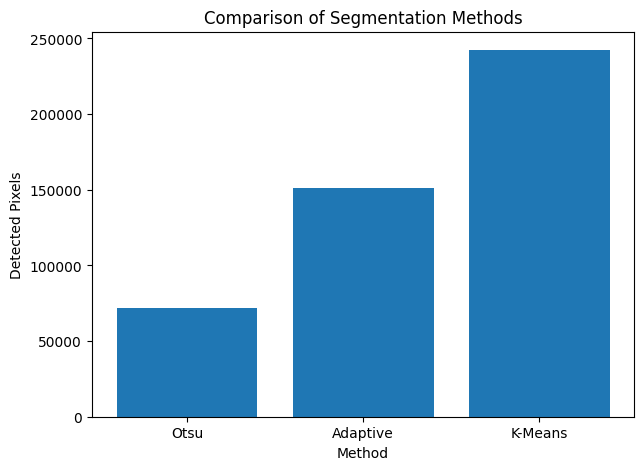

In [ ]:
import matplotlib.pyplot as plt

methods = ["Otsu", "Adaptive", "K-Means"]

pixels = [
    otsu_mask.sum(),
    adaptive_mask.sum(),
    np.sum(clustered == 1)
]

plt.figure(figsize=(7,5))
plt.bar(methods, pixels)
plt.title("Comparison of Segmentation Methods")
plt.ylabel("Detected Pixels")
plt.xlabel("Method")
plt.show()